In [1]:
import os
import pprint
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
torch.cuda.is_available()
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import Dataset, CacheDataset, DataLoader, ThreadDataLoader
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet169
from monai.transforms import (
    Activations,
    AsDiscrete,
    EnsureChannelFirstd,
    EnsureTyped,
    Compose,
    ConcatItemsd,
    LoadImaged,
    RandFlipd,
    RandRotate90d,
    RandZoomd,
    ScaleIntensityRangePercentilesd,
)
from monai.utils import set_determinism
from sklearn.preprocessing import LabelEncoder

print_config()

MONAI version: 1.4.0
Numpy version: 1.26.4
Pytorch version: 2.5.1
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: C:\Users\<username>\AppData\Local\anaconda3\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.1.0
scikit-image version: 0.20.0
scipy version: 1.14.1
Pillow version: 10.4.0
Tensorboard version: 2.20.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.20.1
tqdm version: 4.66.5
lmdb version: 1.4.1
psutil version: 5.9.0
pandas version: 2.0.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: 1.1.1
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please 

In [ ]:
# ============================================================
#  PATHS -- EDIT THESE TO MATCH YOUR OWN DIRECTORIES
#  Every file/folder location used in this notebook is set here.
#  Change each path to fit your own setup before running.
# ============================================================

# Dataset root for this channel (must contain train/, val/, test/ subfolders)
base_path = "./QUAC_8_classes/H3K4me1/"

# Trained weights to load (used by the "load trained model" cell)
pretrained_model_path = "QUAC_model/eight_classes_model/H3K4me1_50epochs_model.pth"

# Output file for the held-out test classification report
test_report_path = "Monai_8_classes_H3K4me1_TEST.txt"

# Where to save the trained model after training
save_model_path = "QUAC_model/eight_classes_model/DAPI_50epochs_model.pth"
save_jit_path   = "QUAC_model/eight_classes_model/DAPI_50epochs_jit.pt"


In [2]:
torch.cuda.is_available()

True

In [5]:
# Define dataset paths (base_path is set in the PATHS cell at the top)
train_dir = os.path.join(base_path, "train")
val_dir   = os.path.join(base_path, "val")
test_dir  = os.path.join(base_path, "test")      # held-out 20% split (70/10/20)

# List all class names (subdirectory names)
classes = sorted(os.listdir(train_dir))  # ['astrocyte', 'neuron']
class_map = {c: idx for idx, c in enumerate(classes)}
num_classes = len(classes)

# Encode labels using class_map
def encode_label(path):
    class_name = os.path.basename(os.path.dirname(path))
    return class_map[class_name]

# Build a list of image paths and their corresponding labels
def build_datalist(data_dir):
    datalist = []
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for image_name in os.listdir(class_dir):
            if image_name.lower() == "thumbs.db":
                continue
            image_path = os.path.join(class_dir, image_name)
            label = encode_label(image_path)
            datalist.append({"image": image_path, "label": label})
    return datalist

train_datalist = build_datalist(train_dir)
val_datalist   = build_datalist(val_dir)
test_datalist  = build_datalist(test_dir)   # held-out test set

In [7]:
pp = pprint.PrettyPrinter()
pp.pprint(train_datalist[:3])

[{'image': './QUAC_8_classes/H3K4me1/train\\0\\cell107451.tiff', 'label': 0},
 {'image': './QUAC_8_classes/H3K4me1/train\\0\\cell107636.tiff', 'label': 0},
 {'image': './QUAC_8_classes/H3K4me1/train\\0\\cell107676.tiff', 'label': 0}]


In [9]:
# Define your folder-to-class mapping 
folder_to_class = {
    "0": "CTX-Glut",
    "5": "CTX-Olig",
    "8": "CTX-GABA",
    "11": "CTX-Astro",
    "13": "ExN Gluta TH",
    "16": "ExN CA1",
    "19": "ExN CA3",
    "22": "ExN cortex layer"
}

# Create the class_map that maps folder names to sequential indices
classes = sorted(os.listdir(train_dir))  
class_map = {c: idx for idx, c in enumerate(classes)} 

# Create inverse mapping for visualization: sequential index -> class name
class_map_inv = {idx: folder_to_class[folder_name] for folder_name, idx in class_map.items()}


num_classes = len(classes)
class_names = list(class_map_inv.values())


In [11]:
class_names

['CTX-Glut',
 'CTX-Astro',
 'ExN Gluta TH',
 'ExN CA1',
 'ExN CA3',
 'ExN cortex layer',
 'CTX-Olig',
 'CTX-GABA']

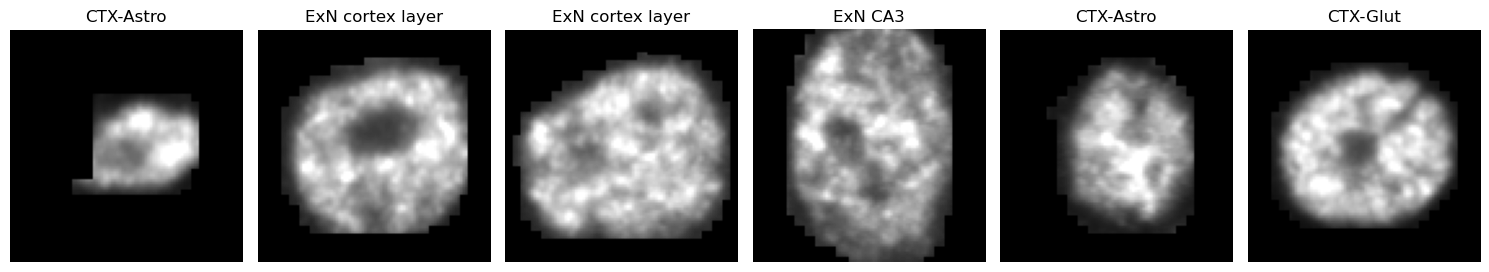

In [13]:
# visualize test batch with normalization
set_determinism(seed=0)
transforms_visualize = Compose(
    [
        LoadImaged(keys=['image'], reader="PILReader", image_only=True),
        EnsureChannelFirstd(keys=['image']),
        ScaleIntensityRangePercentilesd(
            keys=['image'], lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        # ConcatItemsd(keys=["image"], name="image", dim=0),
    ]
)

batch_size_viz = 6
viz_ds = Dataset(train_datalist, transform=transforms_visualize)
viz_loader = DataLoader(viz_ds, batch_size=batch_size_viz, shuffle=True, num_workers=0)
batch_data = next(iter(viz_loader))

fig, axs = plt.subplots(1, batch_size_viz, figsize=(15,5))   #(10, 10 * batch_size_viz), dpi=100)
for idx in range(batch_size_viz):
    img = batch_data['image'][idx].squeeze().numpy()  # Remove channel dimension if needed
    axs[idx].imshow(img, cmap="gray")
    axs[idx].axis("off")
    label = int(batch_data['label'][idx])
    label_name = class_map_inv.get(label, f"Unknown ({label})")
    axs[idx].set_title(label_name)
fig.tight_layout()
plt.show()

In [15]:
num_classes = 8 # Replace with your actual number of classes.

# Keys for your dataset
keys = ["image"]

# Training Transforms
transforms_train = Compose(
    [
        LoadImaged(keys=keys, reader="PILReader", image_only=True),
        EnsureChannelFirstd(keys=keys),
        ScaleIntensityRangePercentilesd(
            keys=keys, lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        ConcatItemsd(keys=keys, name="image", dim=0),
        EnsureTyped(keys=["image", "label"], track_meta=False),
        RandRotate90d(keys=["image"], prob=0.75),
        RandFlipd(keys=["image"], spatial_axis=[0, 1], prob=0.5),
        RandZoomd(keys=["image"], min_zoom=0.9, max_zoom=1.1, prob=0.5),
    ]
)

# Validation Transforms
transforms_val = Compose(
    [
        LoadImaged(keys=keys, reader="PILReader", image_only=True),
        EnsureChannelFirstd(keys=keys),
        ScaleIntensityRangePercentilesd(
            keys=keys, lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        ConcatItemsd(keys=keys, name="image", dim=0),
    ]
)

# Output Transformations
y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=num_classes)])

# Training Dataset and DataLoader
batch_size_train = 8
train_ds = CacheDataset(data=train_datalist, transform=transforms_train, num_workers=10)
train_loader = ThreadDataLoader(train_ds, batch_size=batch_size_train, shuffle=True)

# Validation Dataset and DataLoader
val_ds = CacheDataset(data=val_datalist, transform=transforms_val, num_workers=10)
val_loader = ThreadDataLoader(val_ds, batch_size=batch_size_train, shuffle=True)

Loading dataset: 100%|████████████████████████████████████████████████████████████| 1436/1436 [00:04<00:00, 310.67it/s]


In [22]:
# Start training from DenseNet model
device = "cuda:0"
model = DenseNet169(spatial_dims=2, in_channels=1, out_channels=num_classes, pretrained=True)

In [ ]:
# Or load trained model for further training
# Don't run these codes if you want to start from DenseNet model (first time training)

# device = torch.device("cuda:0")

# # Create the same model architecture as before
# model = DenseNet169(
#     spatial_dims=2,
#     in_channels=1,
#     out_channels=8,    # number of classes
#     pretrained=False  # Turn off ImageNet weights when resuming your own
# )

# # Load the trained 8-class weights for this channel (matches the reported numbers)
# model.load_state_dict(torch.load(pretrained_model_path,
#                                  map_location=device, weights_only=True))

# model.to(device)
# model.eval()

In [24]:
model.to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 5e-5)
max_epochs = 50             # can increase or decrease. Recommend 5 epochs for a short test first. 50 epochs may take hours depending on dataset
val_interval = 1
auc_metric = ROCAUCMetric()

In [26]:
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
        epoch_len = len(train_ds) // train_loader.batch_size
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

----------
epoch 1/50
1/1263, train_loss: 2.4470
2/1263, train_loss: 2.1124
3/1263, train_loss: 2.1915
4/1263, train_loss: 2.3497
5/1263, train_loss: 2.0529
6/1263, train_loss: 1.9256
7/1263, train_loss: 2.2105
8/1263, train_loss: 1.8964
9/1263, train_loss: 1.9818
10/1263, train_loss: 1.7569
11/1263, train_loss: 2.0699
12/1263, train_loss: 1.7803
13/1263, train_loss: 2.5317
14/1263, train_loss: 2.2369
15/1263, train_loss: 1.7782
16/1263, train_loss: 1.9461
17/1263, train_loss: 1.9226
18/1263, train_loss: 1.7303
19/1263, train_loss: 2.3362
20/1263, train_loss: 1.7376
21/1263, train_loss: 1.8043
22/1263, train_loss: 1.8914
23/1263, train_loss: 1.6557
24/1263, train_loss: 2.3231
25/1263, train_loss: 2.3678
26/1263, train_loss: 1.8686
27/1263, train_loss: 2.0589
28/1263, train_loss: 1.5761
29/1263, train_loss: 1.9309
30/1263, train_loss: 2.0791
31/1263, train_loss: 1.7371
32/1263, train_loss: 1.7029
33/1263, train_loss: 1.5548
34/1263, train_loss: 1.7055
35/1263, train_loss: 1.6799
36/1263

In [19]:
# ---- Evaluate on the HELD-OUT TEST set (70/10/20 split), NOT val ----
# val/ is used during training for monitoring; test/ is untouched.
batch_size_test = 32
test_ds = Dataset(test_datalist, transform=transforms_val)
test_loader = DataLoader(test_ds, batch_size=batch_size_test, shuffle=False, num_workers=0)

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = (
            test_data["image"].to(device),
            test_data["label"].to(device),
        )
        pred = model(test_images).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(f"H3K4me1  --  HELD-OUT TEST set (n={len(test_datalist)})\n")
print(report)

# Save the held-out test report 
with open(test_report_path, "w") as f:
    f.write(f"H3K4me1  --  HELD-OUT TEST set (n={len(test_datalist)})\n\n")
    f.write(report)

H3K4me1  --  HELD-OUT TEST set (n=2863)

                  precision    recall  f1-score   support

        CTX-Glut     0.5731    0.6136    0.5927       396
       CTX-Astro     0.8231    0.9260    0.8715       392
    ExN Gluta TH     0.7126    0.6713    0.6913       362
         ExN CA1     0.6148    0.5541    0.5829       314
         ExN CA3     0.6203    0.5460    0.5807       359
ExN cortex layer     0.6088    0.7311    0.6644       264
        CTX-Olig     0.9768    0.9870    0.9819       384
        CTX-GABA     0.6487    0.5842    0.6148       392

        accuracy                         0.7056      2863
       macro avg     0.6973    0.7017    0.6975      2863
    weighted avg     0.7033    0.7056    0.7026      2863



<Figure size 1000x800 with 0 Axes>

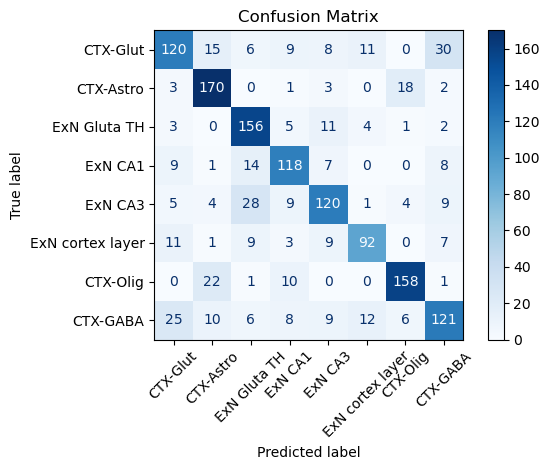

In [28]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot 
plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [29]:
torch.save(model.state_dict(), save_model_path)

In [30]:
model_script = torch.jit.script(model)
model_script.save(save_jit_path)